# **Base de dados  Airline Passengers**

A base de dados Airline Passengers (também conhecida como "International Airline Passengers") é um conjunto de dados clássico para análise e previsão de séries temporais, a base contém  o  mensal de passageiros de companhias aéreas internacionais (em milhares; abrange o período de  Janeiro 1949 a Dezembro 1960 (12 anos), portanto, conta com 144 observações resultadod e (12 meses × 12 anos).

**Características:**

* **Tendência crescente clara.**

*  **Sazonalidade anual (picos em períodos de férias).**

*  **Não estacionária (média e variância mudam ao longo do tempo**

# 1. **Carregar os dados**


In [1]:
#Importanto a base de deprecated_endpoints
print("="*70)
print("CARREGAR E EXPLORAR OS DADOS")
print("="*70)


import pandas as pd
import numpy as np
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
base = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

df = base.copy()
passengers = df['Passengers'].values.astype('float32')

CARREGAR E EXPLORAR OS DADOS


In [2]:
base.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [3]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [4]:
df.tail()

,Passengers
Month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


In [5]:
base.shape

(144, 1)

In [6]:
base.isnull().sum()

,0
Passengers,0


In [7]:
base.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [8]:
anos =df.index

In [9]:
num_passageiros =df.iloc[:,0]

In [10]:
base.shape

(144, 1)

In [11]:
base.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


# 2. **Análise exploratória dos dados**

In [12]:
print(f"\n ANÁLISE DO DATASET AIR PASSENGERS:")
print(f"   • Período: {df.index.min().strftime('%Y-%m')} até {df.index.max().strftime('%Y-%m')}")
print(f"   • Total de meses: {len(df)}")
print(f"   • Média: {np.mean(passengers):.1f} passageiros")
print(f"   • Mínimo: {np.min(passengers)} passageiros")
print(f"   • Máximo: {np.max(passengers)} passageiros")
print(f"   • Desvio Padrão: {np.std(passengers):.1f}")


 ANÁLISE DO DATASET AIR PASSENGERS:
   • Período: 1949-01 até 1960-12
   • Total de meses: 144
   • Média: 280.3 passageiros
   • Mínimo: 104.0 passageiros
   • Máximo: 622.0 passageiros
   • Desvio Padrão: 119.5


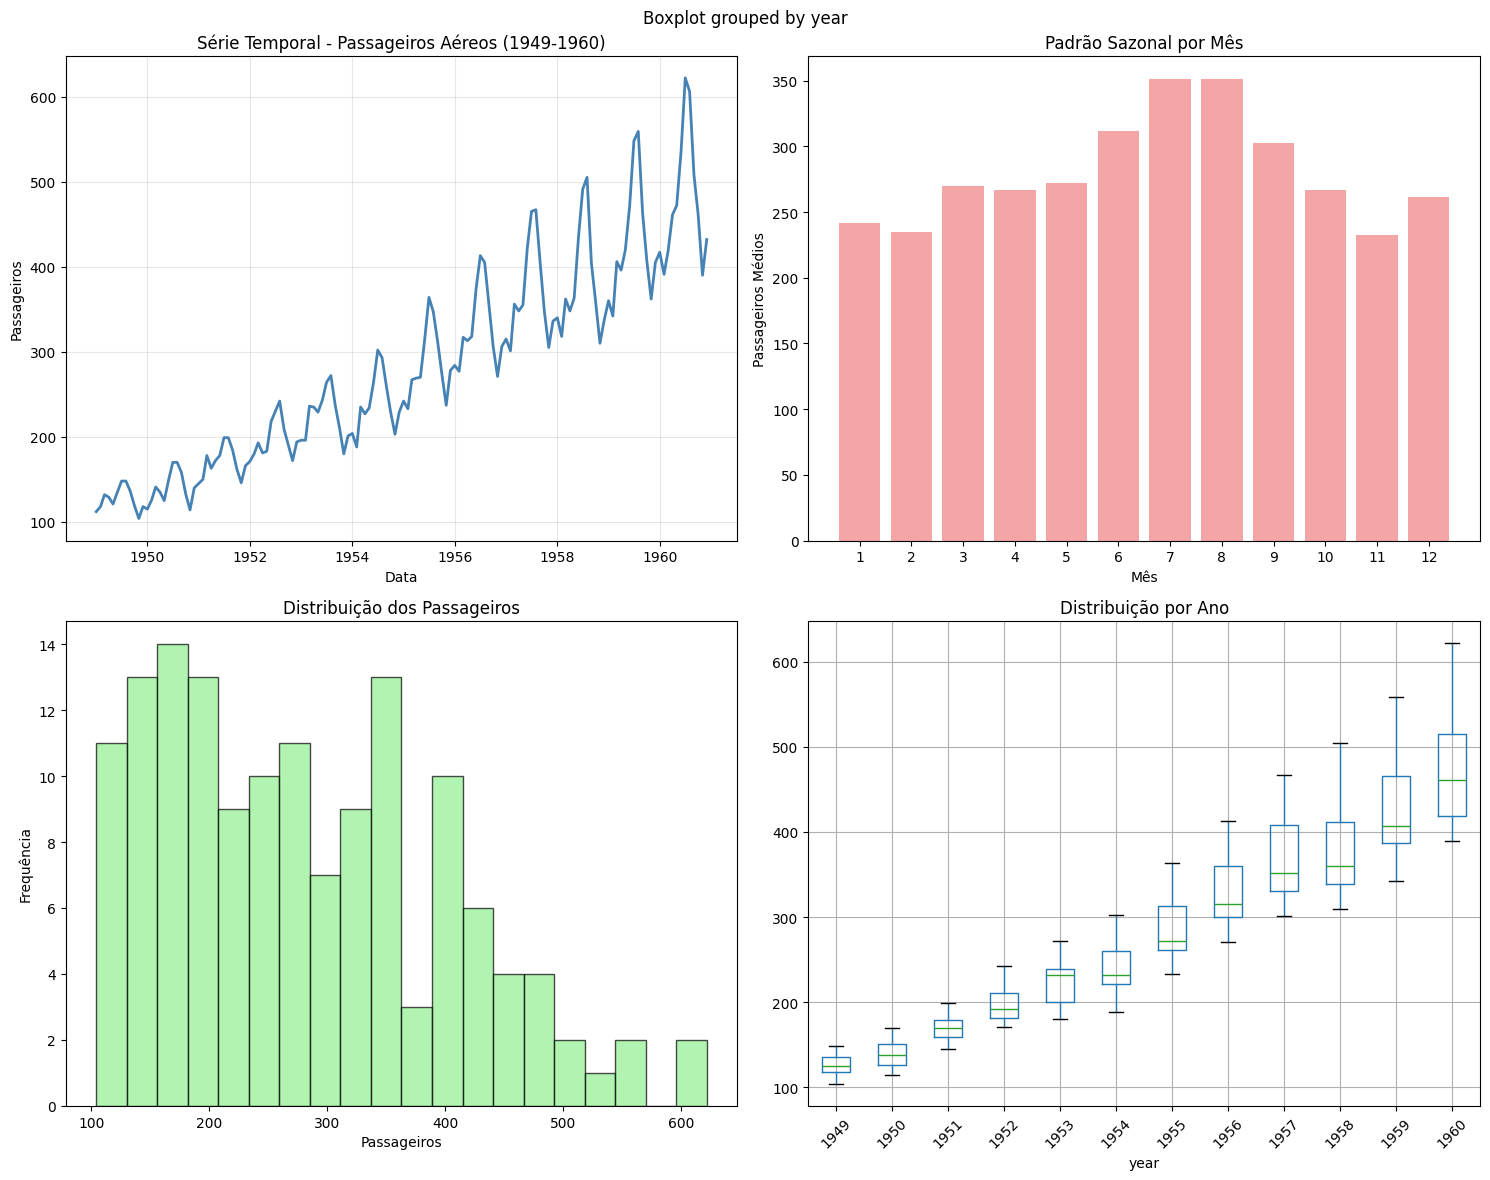

In [13]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Série temporal original
axes[0, 0].plot(df.index, passengers, linewidth=2, color='steelblue')
axes[0, 0].set_title('Série Temporal - Passageiros Aéreos (1949-1960)')
axes[0, 0].set_xlabel('Data')
axes[0, 0].set_ylabel('Passageiros')
axes[0, 0].grid(True, alpha=0.3)

# Decomposição sazonal
df['month'] = df.index.month
seasonal_avg = df.groupby('month')['Passengers'].mean()
axes[0, 1].bar(range(1, 13), seasonal_avg, color='lightcoral', alpha=0.7)
axes[0, 1].set_title('Padrão Sazonal por Mês')
axes[0, 1].set_xlabel('Mês')
axes[0, 1].set_ylabel('Passageiros Médios')
axes[0, 1].set_xticks(range(1, 13))

# Distribuição
axes[1, 0].hist(passengers, bins=20, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribuição dos Passageiros')
axes[1, 0].set_xlabel('Passageiros')
axes[1, 0].set_ylabel('Frequência')

# Boxplot por ano
df['year'] = df.index.year
df.boxplot(column='Passengers', by='year', ax=axes[1, 1])
axes[1, 1].set_title('Distribuição por Ano')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3. **Tensorflow**

O **TensorFlow** é um framework de **código aberto** para **aprendizado de máquina e deep learning**, desenvolvido pelo **Google Brain Team**. Ele é amplamente utilizado para criar e treinar modelos de inteligência artificial, especialmente redes neurais.


**Principais Características**

  * **Plataforma Flexível:**
      * Permite construir modelos desde redes neurais simples até arquiteturas complexas (LSTM, CNNs, Transformers).

      * Suporta CPUs, GPUs e TPUs (Unidades de Processamento Tensorial).

      * Computação Baseada em Tensores: Os dados são tratados como tensores (arrays multidimensionais), otimizados para cálculos numéricos.

  * **Ecossistema Completo:**
      * TensorFlow Core: API de baixo nível para controle total.

      * Keras: API de alto nível (integrada ao TF) para prototipagem rápida.

      * TensorFlow Lite: Para deploy em dispositivos móveis/embarcados.

      * TensorFlow.js: Para execução em navegadores.

* **Multiplataforma:**

    * Funciona em Windows, Linux, macOS e até em navegadores web.


In [14]:
base.shape

(144, 1)

In [15]:
# TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout, LSTM


# 4 **Particionando a base de dados**
* X_treinamento, y_treinamento
* X_teste, y_teste

## 4.1 **Construindo as bases de treinamento (X_treinamento, y_treinamento)**

In [16]:
#Serão utilizados aproximadamente 80% dos dados para teinamento e 20% dos dados para teste
#144*0.80= 115.6, portanto aproximadamente 116

nn_base_treinamento = 116
base_treinamento =base.iloc[0:nn_base_treinamento,0].values

In [17]:
base_treinamento =base_treinamento.reshape(-1,1)

In [18]:
base_treinamento.shape

(116, 1)

In [19]:
#Definindo o normalizador
from sklearn.preprocessing import MinMaxScaler
normalizador =MinMaxScaler(feature_range=(0,1))
normalizador_previsores = MinMaxScaler(feature_range=(0,1))

In [20]:
base_treinamento_normalizada =normalizador.fit_transform(base_treinamento)

Definir o intervalo de tempo, quantos dias vou precisar para a previsão do proximo dia

###  4.1.1 **Adequando a base de treinamento a entreda LSTM**

In [21]:
#intervalo utilizado para relizar as previsões futuras é de 12 meses
intervalo_previsao =12

In [22]:
X_treinamento=[] #previsores
y_treinamento =[] #preço real

for i in range(intervalo_previsao,nn_base_treinamento):
    X_treinamento.append(base_treinamento_normalizada[i-intervalo_previsao:i,0])
    y_treinamento.append(base_treinamento_normalizada[i,0])

# Ao final deste loop X conterá em cada uma de suas entradas,
# uma lista do 12 registros.

In [23]:
#Convertendo X e y de Listas para Arrays
X_treinamento = np.array(X_treinamento)
y_treinamento =np.array(y_treinamento)

In [24]:
base.shape

(144, 1)

## 4.2  **Construindo as bases de teste (X_teste, y_teste)**

In [ ]:
# A base de teste será composta pelos elementos que estão
# apos a posição limite da base de treino, ou seja, após a posição 116

base_teste = base.iloc[nn_base_treinamento:,0].values

In [ ]:
y_teste = base_teste.copy()

In [ ]:
y_teste

array([404, 359, 310, 337, 360, 342, 406, 396, 420, 472, 548, 559, 463,
       407, 362, 405, 417, 391, 419, 461, 472, 535, 622, 606, 508, 461,
       390, 432])

### 4.2.2 **Adequando a base de teste a entreda LSTM**

In [ ]:
base_teste.shape

(28,)

In [ ]:
base_teste =base_teste.reshape(-1,1)

In [ ]:
base_teste.shape

(28, 1)

In [ ]:
base.shape

(144, 1)

In [ ]:
#base contem todos os dados
base_completa = base

In [ ]:
len(base_completa), len(base_teste)

(144, 28)

In [ ]:
entradas = base_completa[len(base_completa) - len(base_teste) - intervalo_previsao:].values

In [ ]:
# Formato de vetor
entradas.shape

(40, 1)

In [ ]:
#Transformando o formato vetor para o formato matriz
entradas = entradas.reshape(-1, 1)
entradas.shape

(40, 1)

In [ ]:
entradas

array([[404],
       [347],
       [305],
       [336],
       [340],
       [318],
       [362],
       [348],
       [363],
       [435],
       [491],
       [505],
       [404],
       [359],
       [310],
       [337],
       [360],
       [342],
       [406],
       [396],
       [420],
       [472],
       [548],
       [559],
       [463],
       [407],
       [362],
       [405],
       [417],
       [391],
       [419],
       [461],
       [472],
       [535],
       [622],
       [606],
       [508],
       [461],
       [390],
       [432]])

In [ ]:
##Normalizando os dados de entrada
entradas_normalizadas = normalizador.transform(entradas)

In [ ]:
base.shape

(144, 1)

In [ ]:
X_teste = []
nn_entradas =len(entradas)
for i in range(intervalo_previsao, nn_entradas):
  #print(i)
  X_teste.append(entradas_normalizadas[i - intervalo_previsao:i, 0])






In [ ]:
X_teste_array =np.array(X_teste)



In [ ]:
X_teste_array.shape[0]

28

In [ ]:
X_teste_array.shape[1]

12

In [ ]:
X_teste_array = np.reshape(X_teste_array,( X_teste_array.shape[0],X_teste_array.shape[1],1))

In [ ]:
# X_teste_array , possui 28  linhas, cada linha possui 12 registros, tudo em uma unica coluna

# 5. **Construindo a Rede Neural LSTM**

In [ ]:
X_treinamento.shape[1]

12

In [ ]:
from tensorflow.keras.models import Sequential
regressor = Sequential()

regressor.add(LSTM(units = 200, return_sequences=True, input_shape = (X_treinamento.shape[1], 1)))
regressor.add(Dropout(0.1))

regressor.add(LSTM(units = 150, return_sequences=True))
regressor.add(Dropout(0.1))

regressor.add(LSTM(units = 100, return_sequences=True))
regressor.add(Dropout(0.1))

regressor.add(LSTM(units = 50, return_sequences=True))
regressor.add(Dropout(0.1))

regressor.add(LSTM(units = 25))
regressor.add(Dropout(0.1))

regressor.add(Dense(units = 1, activation = 'linear'))

regressor.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 200)        │       161,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 150)        │       210,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 100)        │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 12, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 510,426 (1.95 MB)

 Trainable params: 510,426 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mean_absolute_error'])

In [ ]:
regressor.fit(X_treinamento, y_treinamento, epochs = 200, batch_size = 40)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.1582 - mean_absolute_error: 0.3388
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0632 - mean_absolute_error: 0.1886
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0377 - mean_absolute_error: 0.1752
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0206 - mean_absolute_error: 0.1129
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0326 - mean_absolute_error: 0.1334
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0182 - mean_absolute_error: 0.1010
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0181 - mean_absolute_error: 0.1174
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0134 - mean_absolute_error: 0.0963
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0132 - mean_absolute_error: 0.0803
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0098 - mean_absolute_error: 0.0736
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/s

# 6 **Realizando as previsões**

In [ ]:
X_teste_array

array([[[0.74812968],
        [0.60598504],
        [0.50124688],
        [0.57855362],
        [0.58852868],
        [0.53366584],
        [0.64339152],
        [0.6084788 ],
        [0.64588529],
        [0.82543641],
        [0.96508728],
        [1.        ]],

       [[0.60598504],
        [0.50124688],
        [0.57855362],
        [0.58852868],
        [0.53366584],
        [0.64339152],
        [0.6084788 ],
        [0.64588529],
        [0.82543641],
        [0.96508728],
        [1.        ],
        [0.74812968]],

       [[0.50124688],
        [0.57855362],
        [0.58852868],
        [0.53366584],
        [0.64339152],
        [0.6084788 ],
        [0.64588529],
        [0.82543641],
        [0.96508728],
        [1.        ],
        [0.74812968],
        [0.63591022]],

       [[0.57855362],
        [0.58852868],
        [0.53366584],
        [0.64339152],
        [0.6084788 ],
        [0.64588529],
        [0.82543641],
        [0.96508728],
        [1.        ],
    

In [ ]:
previsores_normalizados =regressor.predict(X_teste_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step


In [ ]:
previsores_normalizados

array([[0.93374115],
       [0.800491  ],
       [0.73548234],
       [0.781699  ],
       [0.7620921 ],
       [0.7413166 ],
       [0.8029982 ],
       [0.81672496],
       [0.8979288 ],
       [1.0077043 ],
       [1.0748911 ],
       [1.0738995 ],
       [0.9293243 ],
       [0.8083316 ],
       [0.73003656],
       [0.7804619 ],
       [0.79648745],
       [0.7866318 ],
       [0.8506771 ],
       [0.8531689 ],
       [0.9128877 ],
       [0.99515456],
       [1.0698748 ],
       [1.0829027 ],
       [0.99446356],
       [0.9074973 ],
       [0.8572944 ],
       [0.8916537 ]], dtype=float32)

In [ ]:
#Aplicando a transformação inversa do normalizador
previsores_reais =normalizador.inverse_transform(previsores_normalizados)

In [ ]:
previsores_reais

array([[478.43024],
       [424.9969 ],
       [398.9284 ],
       [417.46133],
       [409.59894],
       [401.26797],
       [426.00226],
       [431.5067 ],
       [464.06946],
       [508.08942],
       [535.0313 ],
       [534.6337 ],
       [476.6591 ],
       [428.14096],
       [396.74466],
       [416.9652 ],
       [423.39145],
       [419.43936],
       [445.12152],
       [446.12076],
       [470.06796],
       [503.057  ],
       [533.0198 ],
       [538.24396],
       [502.77988],
       [467.9064 ],
       [447.77505],
       [461.55316]], dtype=float32)

In [ ]:
y_teste

array([404, 359, 310, 337, 360, 342, 406, 396, 420, 472, 548, 559, 463,
       407, 362, 405, 417, 391, 419, 461, 472, 535, 622, 606, 508, 461,
       390, 432])

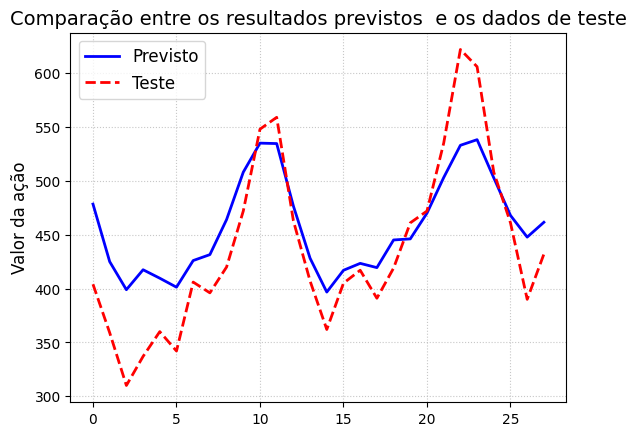

In [ ]:
# Plotando as duas curvas

plt.plot( previsores_reais, 'b-', linewidth=2, label='Previsto')      # Curva azul
plt.plot( y_teste, 'r--', linewidth=2, label='Teste')  # Curva vermelha tracejada

# Personalizando o gráfico
plt.title('Comparação entre os resultados previstos  e os dados de teste', fontsize=14)
plt.ylabel('Valor da ação', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)  # Grade pontilhada
plt.legend(fontsize=12, loc='best')  # Legenda



# Mostrando o gráfico
plt.show()

In [ ]:
from sklearn.metrics  import  mean_absolute_error

In [ ]:
mean_absolute_error(y_teste,previsores_reais)

37.11050033569336